# Punto 2 y 3: Estrategia de análisis y desarrollo

Este notebook desarrolla los puntos 2 y 3 del Taller 1 de MINE-4101. Parte de los
datos ya tratados en 01_entendimiento_inicial.ipynb, que debe ejecutarse primero para
generar data/secop_bienes_limpio.parquet.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)

df_limpio = pd.read_parquet('../data/secop_bienes_limpio.parquet')
print(df_limpio.shape)

(196391, 41)


## 2. Estrategia de análisis

La estrategia parte de los tres hallazgos cuantificados en el punto 1, el 9.51% de los
contratos tuvo adición de plazo, con una cola de extensiones que llega hasta 874 días
una vez corregidos los errores de fecha, el 21.79% de todos los contratos terminó o se
cerró sin haber ejecutado ni un peso del presupuesto comprometido, y el 55.31% de los
contratos cerrados o terminados no está liquidado. Estas tres cifras son la variable de
salida que se quiere explicar, y la pregunta central de la estrategia es qué
características del contrato, como su valor, la modalidad de contratación, el sector, el
departamento o el tipo de entidad, se asocian con que un contrato caiga en alguno de
estos tres grupos de riesgo. Para responder esto se sigue una progresión de menor a
mayor complejidad, empezando por estadísticos descriptivos y proporciones por grupo, por
ejemplo el porcentaje de contratos sin liquidar dentro de cada modalidad de
contratación, siguiendo con pruebas de hipótesis formales que confirmen si esas
diferencias observadas son estadísticamente significativas o podrían deberse al azar, y
cerrando con visualizaciones que crucen varios atributos al tiempo para ver
combinaciones de características, no solo variables aisladas.

La elección de la prueba depende del tipo de variable y del número de grupos que se
comparan. Para variables numéricas como dias_adicionados o duracion_dias comparadas
entre más de dos categorías, como las 9 modalidades de contratación o los sectores, se
usa ANOVA de un factor, seguido de una prueba post hoc de Tukey para identificar
específicamente cuáles pares de grupos difieren entre sí, en vez de quedarse solo con la
conclusión genérica de que existe alguna diferencia. Para comparar dos grupos puntuales
se usa la prueba t de Welch, que no asume varianzas iguales entre los grupos, y para las
tres señales de desviación, que son esencialmente proporciones, contrato con o sin
liquidar, con o sin ejecución de presupuesto, se usa la prueba de chi cuadrado de
independencia contra variables categóricas como modalidad, sector o departamento,
verificando primero que las frecuencias esperadas sean suficientes para que la prueba
sea válida. En todos los casos se revisan los supuestos antes de interpretar el
resultado, y se reporta el tamaño del efecto, como Cramér's V para las pruebas de chi
cuadrado, además del valor p, porque una asociación puede ser estadísticamente
significativa con un tamaño de muestra grande como este y aun así ser irrelevante en la
práctica. Antes de cada prueba se define además qué diferencia sería lo suficientemente
grande como para justificar un cambio en la estrategia de supervisión, para no basar la
decisión únicamente en si el p valor cruza el umbral de 0.05.La parte visual de la estrategia no se limita a graficar una variable a la vez, incluye
cruces de al menos tres atributos, por ejemplo el valor del contrato contra la
modalidad de contratación, diferenciando además por si el contrato quedó liquidado o
no, para identificar visualmente qué combinaciones concentran el mayor riesgo. Todo
este análisis se hace sobre las columnas ya marcadas como confiables en el punto 1,
respetando las banderas de calidad construidas

## 3. Desarrollo de la estrategia

### 3.1 ¿La modalidad de contratación se asocia con adiciones de plazo más largas?

**Paso 0. Umbral de relevancia práctica.** Antes de probar nada, se define qué
diferencia importaría en la práctica. Una diferencia de al menos 15 días entre
modalidades se considera relevante para la estrategia de supervisión, aproximadamente
la mitad de la mediana de 31 días que se observó en el punto 1 para los contratos que
sí tuvieron adición.

**Paso 1. Hipótesis.**
H0: el promedio de dias_adicionados es igual entre las 9 modalidades de contratación.
H1: al menos una modalidad tiene un promedio distinto.

In [25]:
from scipy import stats

resumen_modalidad = df_limpio.groupby('modalidad_de_contratacion')['dias_adicionados'].agg(['count', 'mean', 'median', 'std']).round(2)
print(resumen_modalidad.sort_values('median', ascending=False))

                                                     count   mean  median  \
modalidad_de_contratacion                                                   
Contratación Directa (con ofertas)                    5001   5.54     0.0   
Contratación directa                                  3938   5.35     0.0   
Contratación régimen especial                        19250   3.67     0.0   
Contratación régimen especial (con ofertas)           6154  14.21     0.0   
Licitación pública                                    2330  18.65     0.0   
Mínima cuantía                                      117752   2.93     0.0   
Selección Abreviada Menor Cuantía Sin Manifesta...     236  17.74     0.0   
Selección Abreviada de Menor Cuantía                  8822   8.35     0.0   
Selección abreviada subasta inversa                  32907   9.60     0.0   

                                                      std  
modalidad_de_contratacion                                  
Contratación Directa (con oferta

**Paso 2. Verificación de supuestos.** El punto 1 ya mostró que dias_adicionados tiene
el 90.49% de sus valores en cero, una distribución completamente alejada de la
normalidad que requiere ANOVA. Por eso, en vez de forzar ANOVA, se usa Kruskal-Wallis,
la alternativa no paramétrica que compara las distribuciones de más de dos grupos sin
asumir normalidad.

**Paso 3. Prueba adecuada y cálculo.**

In [26]:
grupos = [g['dias_adicionados'].dropna().values for _, g in df_limpio.groupby('modalidad_de_contratacion')]
h_stat, p_value = stats.kruskal(*grupos)

print('Kruskal-Wallis: H =', h_stat, ', p =', p_value)

Kruskal-Wallis: H = 4327.167710039168 , p = 0.0


**Paso 4. Tamaño del efecto.**

In [27]:
k = df_limpio['modalidad_de_contratacion'].nunique()
n = df_limpio['dias_adicionados'].notna().sum()
eta_cuadrado = (h_stat - k + 1) / (n - k)
print('Numero de grupos:', k, ', tamano de muestra:', n)
print('Tamaño del efecto (eta cuadrado):', round(eta_cuadrado, 4))

Numero de grupos: 9 , tamano de muestra: 196390
Tamaño del efecto (eta cuadrado): 0.022


**Paso 5. Comparación puntual entre los dos extremos.** Con 9 modalidades hay 36
comparaciones posibles, pero la más relevante para la estrategia es la de los dos
extremos, Licitación pública contra Mínima cuantía, que concentra además la mayoría de
los contratos (59.96%). Como las medianas son cero en ambas por la concentración de
ceros, se usa Mann-Whitney U en vez de comparar solo promedios, que no asume
normalidad y compara si una distribución tiende a tener valores más altos que la otra.

In [28]:
licitacion = df_limpio.loc[df_limpio['modalidad_de_contratacion'] == 'Licitación pública', 'dias_adicionados'].dropna()
minima = df_limpio.loc[df_limpio['modalidad_de_contratacion'] == 'Mínima cuantía', 'dias_adicionados'].dropna()

u_stat, p_valor_par = stats.mannwhitneyu(licitacion, minima, alternative='two-sided')

print('Mann-Whitney U (Licitación pública vs Mínima cuantía): U =', u_stat, ', p =', p_valor_par)
print('Diferencia de promedios:', round(licitacion.mean() - minima.mean(), 2), 'días')

Mann-Whitney U (Licitación pública vs Mínima cuantía): U = 163548994.5 , p = 1.183259727587737e-264
Diferencia de promedios: 15.72 días


**Paso 6. Interpretación.**

El tamaño del efecto general (eta cuadrado = 0.022) es pequeño, la modalidad de
contratación como factor completo explica apenas el 2.2% de la variación en
dias_adicionados entre las 196390 filas con dato. Esto significa que, en general, la
modalidad no es un buen predictor aislado de cuánto se adiciona un contrato.

Sin embargo, la comparación puntual entre los dos extremos sí es relevante en la
práctica. Licitación pública tiene un promedio de adición de 18.65 días frente a 2.93
días en Mínima cuantía, una diferencia de 15.72 días que supera el umbral de 15 días
definido antes de la prueba, y la diferencia es además estadísticamente significativa
(Mann-Whitney U, p menor a 0.001). Esto no contradice el tamaño del efecto pequeño, lo
complementa, el efecto general es pequeño porque la mayoría de las modalidades se
parecen entre sí cerca del promedio general, pero Licitación pública en particular sí
se separa de forma relevante del resto, en especial de Mínima cuantía, que concentra el
59.96% de todos los contratos.

En conclusión, la modalidad de contratación por sí sola no es un criterio fuerte de
focalización para dias_adicionados, pero Licitación pública sí muestra una tendencia
consistente a adiciones de plazo más largas, y debería considerarse como un factor
adicional dentro de un criterio compuesto de supervisión, no como el único criterio.

### 3.2 ¿La modalidad de contratación se asocia con presupuesto no ejecutado?

**Paso 0. Umbral de relevancia práctica.** Se considera relevante una diferencia de al
menos 10 puntos porcentuales entre modalidades en la proporción de contratos cerrados
o terminados sin ejecutar presupuesto, dado que la tasa general ya es alta, 21.79% de
todos los contratos.

**Paso 1. Hipótesis.**
H0: la proporción de contratos sin ejecutar presupuesto es independiente de la
modalidad de contratación.
H1: la proporción depende de la modalidad de contratación.

In [29]:
df_limpio['no_ejecutado'] = df_limpio['estado_contrato'].isin(['Terminado', 'Cerrado']) & (df_limpio['valor_pagado'] == 0)

tabla_ejecucion = pd.crosstab(df_limpio['modalidad_de_contratacion'], df_limpio['no_ejecutado'])
print(tabla_ejecucion)
print()
proporciones = (pd.crosstab(df_limpio['modalidad_de_contratacion'], df_limpio['no_ejecutado'], normalize='index') * 100).round(2)
print(proporciones)

no_ejecutado                                        False  True 
modalidad_de_contratacion                                       
Contratación Directa (con ofertas)                   3780   1221
Contratación directa                                 2958    980
Contratación régimen especial                       14066   5184
Contratación régimen especial (con ofertas)          3776   2378
Licitación pública                                   1856    474
Mínima cuantía                                      94137  23616
Selección Abreviada Menor Cuantía Sin Manifesta...    179     57
Selección Abreviada de Menor Cuantía                 6567   2255
Selección abreviada subasta inversa                 26277   6630

no_ejecutado                                        False  True 
modalidad_de_contratacion                                       
Contratación Directa (con ofertas)                  75.58  24.42
Contratación directa                                75.11  24.89
Contratación régimen esp

**Paso 2 y 3. Supuestos y prueba.** Para chi cuadrado de independencia se requiere que
las frecuencias esperadas sean de al menos 5 en cada celda. Se verifica antes de
interpretar el resultado, y se calcula también Cramér's V como tamaño del efecto, dado
que con un tamaño de muestra tan grande el p valor por sí solo tiende a salir
significativo.

In [30]:
chi2, p_value, dof, esperadas = stats.chi2_contingency(tabla_ejecucion)
print('Chi2 =', chi2, ', p =', p_value, ', grados de libertad =', dof)
print('Minima frecuencia esperada:', esperadas.min())

n = tabla_ejecucion.values.sum()
k_min = min(tabla_ejecucion.shape) - 1
cramers_v = (chi2 / (n * k_min)) ** 0.5
print('Cramér V:', round(cramers_v, 4))

Chi2 = 1703.3925485007555 , p = 0.0 , grados de libertad = 8
Minima frecuencia esperada: 51.4260836800057
Cramér V: 0.0931


**Paso 4. Interpretación.**

El estadístico chi-cuadrado (`chi2` = 1703.39, `p` = 0.0, `df` = 8) muestra una asociación estadísticamente significativa entre `modalidad_de_contratacion` y `no_ejecutado`. El supuesto de frecuencia esperada mínima mayor o igual a 5 se cumple (mínimo de 51.43).

El tamaño del efecto, Cramér's V = 0.0931, corresponde a un efecto pequeño según las convenciones de Cohen para esta tabla, por debajo del umbral de 0.10. Esto significa que en términos globales `modalidad_de_contratacion` explica muy poco de la variabilidad en si un contrato queda con presupuesto no ejecutado.

Ese resultado agregado esconde un patrón puntual relevante. La mayoría de las modalidades se agrupan alrededor de 20% de contratos no ejecutados (`Mínima cuantía` 20.06%, `Licitación pública` 20.34%, `Selección abreviada subasta inversa` 20.15%), pero `Contratación régimen especial (con ofertas)` se aleja de ese grupo con 38.64%, casi el doble. La diferencia entre este último grupo y el resto es de aproximadamente 18.5 puntos porcentuales, una brecha que supera claramente el umbral de 10 puntos definido en el Paso 0.

En conclusión, `modalidad_de_contratacion` por sí sola no es un buen predictor general de `no_ejecutado` (efecto pequeño), pero identifica una modalidad puntual, `Contratación régimen especial (con ofertas)`, que representa un factor de riesgo accionable para el criterio de focalización.

Con esto se cierra la segunda pregunta del Punto 3.

### 3.3 ¿La modalidad de contratación se asocia con el cierre sin liquidar?

Analizamos la tercera señal de desviación identificada en el Punto 1 (55.31% de contratos cerrados o terminados sin liquidar) contra `modalidad_de_contratacion`, siguiendo la misma lógica de umbral de relevancia práctica, prueba estadística y tamaño del efecto usada en 3.1 y 3.2.

**Paso 0. Umbral de relevancia práctica.** Se considera relevante una diferencia de al menos 10 puntos porcentuales entre modalidades.

**Paso 1. Hipótesis.**
H0: la proporción de contratos sin liquidar es independiente de la modalidad de contratación.
H1: la proporción depende de la modalidad de contratación.

In [31]:
# Paso 2. Subconjunto: contratos cerrados o terminados, respetando la bandera de calidad liquidacion_confiable
sub_liquidacion = df_limpio[
    (df_limpio['estado_contrato'].isin(['Cerrado', 'Terminado'])) &
    (df_limpio['liquidacion_confiable'])
].copy()

print(f"Contratos cerrados/terminados con liquidaci_n confiable: {len(sub_liquidacion)}")
print(sub_liquidacion['liquidaci_n'].value_counts())

Contratos cerrados/terminados con liquidaci_n confiable: 101054
liquidaci_n
No    55896
Si    45158
Name: count, dtype: int64


In [32]:
# Paso 3. Bandera binaria y tabla cruzada
sub_liquidacion['sin_liquidar'] = (sub_liquidacion['liquidaci_n'] == 'No').astype(int)

tabla_counts = pd.crosstab(sub_liquidacion['modalidad_de_contratacion'], sub_liquidacion['sin_liquidar'])
tabla_pct = pd.crosstab(sub_liquidacion['modalidad_de_contratacion'], sub_liquidacion['sin_liquidar'], normalize='index') * 100

print("Tabla de conteos")
print(tabla_counts)
print()
print("Porcentaje sin_liquidar (columna 1) por modalidad")
print(tabla_pct[1].sort_values(ascending=False))

# Paso 4. Prueba chi-cuadrado y tamaño del efecto
chi2, p, dof, expected = stats.chi2_contingency(tabla_counts)
print()
print(f"Chi2 = {chi2}, p = {p}, grados de libertad = {dof}")
print(f"Minima frecuencia esperada: {expected.min()}")

n = tabla_counts.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla_counts.shape) - 1)))
print(f"Cramér V: {cramers_v}")

Tabla de conteos
sin_liquidar                                            0      1
modalidad_de_contratacion                                       
Contratación Directa (con ofertas)                   1458   1333
Contratación directa                                  625   1171
Contratación régimen especial                        2500   6473
Contratación régimen especial (con ofertas)           532   2382
Licitación pública                                    631    494
Mínima cuantía                                      27174  34172
Selección Abreviada Menor Cuantía Sin Manifesta...    100     39
Selección Abreviada de Menor Cuantía                 2541   2178
Selección abreviada subasta inversa                  9597   7654

Porcentaje sin_liquidar (columna 1) por modalidad
modalidad_de_contratacion
Contratación régimen especial (con ofertas)                    81.743308
Contratación régimen especial                                  72.138638
Contratación directa                         

**Paso 5. Interpretación.**

El estadístico chi-cuadrado (`chi2` = 3087.58, `p` = 0.0, `df` = 8) muestra una asociación estadísticamente muy significativa entre `modalidad_de_contratacion` y `sin_liquidar`. El supuesto de frecuencia esperada mínima mayor o igual a 5 se cumple (mínimo de 62.11).

El tamaño del efecto, Cramér's V = 0.1748, supera el umbral convencional de efecto "pequeño" (0.10) y se acerca al rango de efecto "moderado" (0.30), siendo el más fuerte de las tres preguntas analizadas en el Punto 3 (eta² = 0.022 en 3.1, Cramér's V = 0.0931 en 3.2).

Frente al promedio general de 55.31% encontrado en el Punto 1, tres modalidades quedan muy por encima: `Contratación régimen especial (con ofertas)` con 81.74%, `Contratación régimen especial` con 72.14%, y `Contratación directa` con 65.20%. En el extremo opuesto, `Selección Abreviada Menor Cuantía Sin Manifestación Interés` (28.06%) y `Licitación pública` (43.91%) quedan claramente por debajo del promedio. La diferencia entre el valor máximo y el mínimo es de aproximadamente 53.7 puntos porcentuales, muy por encima del umbral de 10 puntos.

Un hallazgo relevante es que `Contratación régimen especial (con ofertas)` aparece como grupo de riesgo en dos de las tres señales (no ejecución en 3.2 y sin liquidar aquí), mientras que `Licitación pública`, que fue la modalidad de riesgo en 3.1, aquí se comporta por debajo del promedio. Esto indica que el riesgo no es uniforme por modalidad, y el criterio de focalización compuesto debe reflejar esa diferencia.

Con esto se cierra la tercera pregunta del Punto 3.

### 3.4 Síntesis: hacia un criterio compuesto de focalización

Las tres preguntas de esta sección evaluaron si `modalidad_de_contratacion` explica cada una de las señales de desviación identificadas en el Punto 1, y los resultados no apuntan a una única modalidad problemática sino a un patrón más específico.

- En **adiciones de plazo** (3.1), el efecto global es débil (eta² = 0.022), pero `Licitación pública` presenta en promedio 15.72 días más de adición frente a `Mínima cuantía`, diferencia significativa y por encima del umbral de 15 días.

- En **presupuesto no ejecutado** (3.2), el efecto global también es débil (Cramér's V = 0.0931), pero `Contratación régimen especial (con ofertas)` tiene 38.64% de contratos no ejecutados frente a un grupo mayoritario cercano al 20%.

- En **cierre sin liquidar** (3.3), el efecto es el más fuerte de los tres (Cramér's V = 0.1748), con `Contratación régimen especial (con ofertas)` y `Contratación régimen especial` muy por encima del promedio.

`Contratación régimen especial (con ofertas)` es la única modalidad que aparece como factor de riesgo en dos de las tres señales, lo que la convierte en un candidato natural para un criterio de focalización transversal. `Licitación pública`, en cambio, es un factor de riesgo específico solo para adiciones de plazo. Esto refuerza que un criterio de focalización efectivo no puede basarse en una sola modalidad "riesgosa" en general, sino en la combinación de modalidad y tipo de desviación que se quiera vigilar.

### 3.5 Visualización multivariada: síntesis visual del riesgo por modalidad

Las preguntas 3.1, 3.2 y 3.3 evaluaron por separado si `modalidad_de_contratacion` se asocia con cada una de las tres señales de desviación del Punto 1 (adición de plazo, no ejecución de presupuesto y cierre sin liquidar). Aquí construimos una sola visualización que combina las tres señales para identificar qué modalidades concentran riesgo en más de una dimensión a la vez, lo cual sustenta directamente el criterio de focalización propuesto en 3.4.

                                                    n_contratos  \
modalidad_de_contratacion                                         
Contratación Directa (con ofertas)                         5001   
Contratación directa                                       3938   
Contratación régimen especial                             19250   
Contratación régimen especial (con ofertas)                6154   
Licitación pública                                         2330   
Mínima cuantía                                           117753   
Selección Abreviada Menor Cuantía Sin Manifesta...          236   
Selección Abreviada de Menor Cuantía                       8822   
Selección abreviada subasta inversa                       32907   

                                                    dias_adicionados_promedio  \
modalidad_de_contratacion                                                       
Contratación Directa (con ofertas)                                       5.54   
Contratación direct

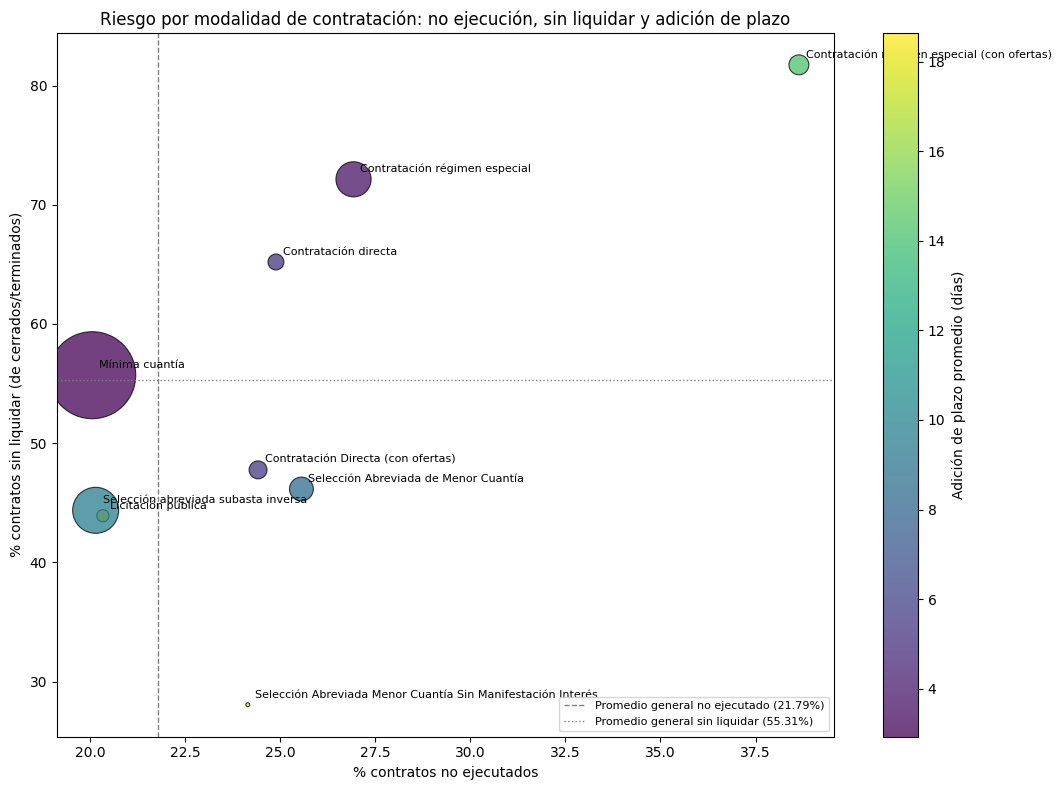

In [33]:
# Construimos una tabla resumen por modalidad con las tres señales de desviación
resumen_modalidad = df_limpio.groupby('modalidad_de_contratacion').agg(
    n_contratos=('modalidad_de_contratacion', 'size'),
    dias_adicionados_promedio=('dias_adicionados', 'mean')
)

resumen_modalidad['pct_no_ejecutado'] = proporciones[True]
resumen_modalidad['pct_sin_liquidar'] = tabla_pct[1]

print(resumen_modalidad.round(2))

# Umbrales de referencia: tasas generales encontradas en el Punto 1
tasa_no_ejecutado_general = 21.79
tasa_sin_liquidar_general = 55.31

fig, ax = plt.subplots(figsize=(11, 8))

scatter = ax.scatter(
    resumen_modalidad['pct_no_ejecutado'],
    resumen_modalidad['pct_sin_liquidar'],
    s=resumen_modalidad['n_contratos'] / 30,
    c=resumen_modalidad['dias_adicionados_promedio'],
    cmap='viridis',
    alpha=0.75,
    edgecolors='black',
    linewidths=0.8
)

for modalidad, fila in resumen_modalidad.iterrows():
    ax.annotate(
        modalidad,
        (fila['pct_no_ejecutado'], fila['pct_sin_liquidar']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points'
    )

ax.axvline(tasa_no_ejecutado_general, color='gray', linestyle='--', linewidth=1, label='Promedio general no ejecutado (21.79%)')
ax.axhline(tasa_sin_liquidar_general, color='gray', linestyle=':', linewidth=1, label='Promedio general sin liquidar (55.31%)')

ax.set_xlabel('% contratos no ejecutados')
ax.set_ylabel('% contratos sin liquidar (de cerrados/terminados)')
ax.set_title('Riesgo por modalidad de contratación: no ejecución, sin liquidar y adición de plazo')
ax.legend(loc='lower right', fontsize=8)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Adición de plazo promedio (días)')

plt.tight_layout()
plt.show()

**Interpretación.**

El gráfico confirma visualmente los hallazgos estadísticos de 3.1 a 3.3. `Contratación régimen especial (con ofertas)` aparece claramente aislada en la esquina superior derecha, con el porcentaje más alto de no ejecución (38.64%) y de cierre sin liquidar (81.74%) de todas las modalidades, lo que la confirma como el foco de riesgo compuesto identificado en la síntesis de 3.4.

`Licitación pública` es un caso distinto e importante. Está por debajo del promedio general en no ejecución (20.34% frente a 21.79%) y en sin liquidar (43.91% frente a 55.31%), pero tiene la adición de plazo promedio más alta de todas las modalidades (18.65 días). Esto confirma visualmente que su riesgo es específico a la dimensión de plazos (hallazgo de 3.1) y no se traslada a las otras dos señales, tal como se planteó en la síntesis.

`Mínima cuantía` concentra el 60% de todos los contratos (n=117753) y se ubica casi exactamente sobre ambas líneas de referencia. Esto no es casualidad, dado su peso en la muestra, es la modalidad que en buena parte define el promedio general, por lo que comparar a las demás modalidades contra ese promedio equivale en parte a compararlas contra `Mínima cuantía` misma.

Una limitación a tener en cuenta es que `Selección Abreviada Menor Cuantía Sin Manifestación Interés` tiene apenas 236 contratos, la burbuja más pequeña del gráfico. Aunque muestra el porcentaje más bajo de cierre sin liquidar (28.06%), ese resultado se apoya en una muestra pequeña y debería tratarse con cautela antes de calificarla como una modalidad de bajo riesgo.

En conjunto, el gráfico muestra que el riesgo de supervisión no se concentra en una sola modalidad de forma homogénea, sino que distintas modalidades destacan en distintas dimensiones. `Contratación régimen especial (con ofertas)` como foco compuesto (no ejecución y sin liquidar), `Licitación pública` como foco específico de adición de plazo, y `Mínima cuantía` como el grupo de referencia dado su volumen. Estos tres perfiles son la base directa del criterio de focalización que se plantea en el Punto 4.

### 3.6 Visualización complementaria: valor del contrato según modalidad y estado de liquidación

Ninguna de las visualizaciones anteriores incluyó `valor_del_contrato`, a pesar de ser uno de los atributos principales del Punto 1 y una variable central para cualquier criterio de focalización de supervisión. Aquí comparamos la distribución del valor del contrato por modalidad, separando entre contratos liquidados y sin liquidar, para ver si el riesgo de no liquidación se concentra en los contratos de mayor o de menor valor dentro de cada modalidad.

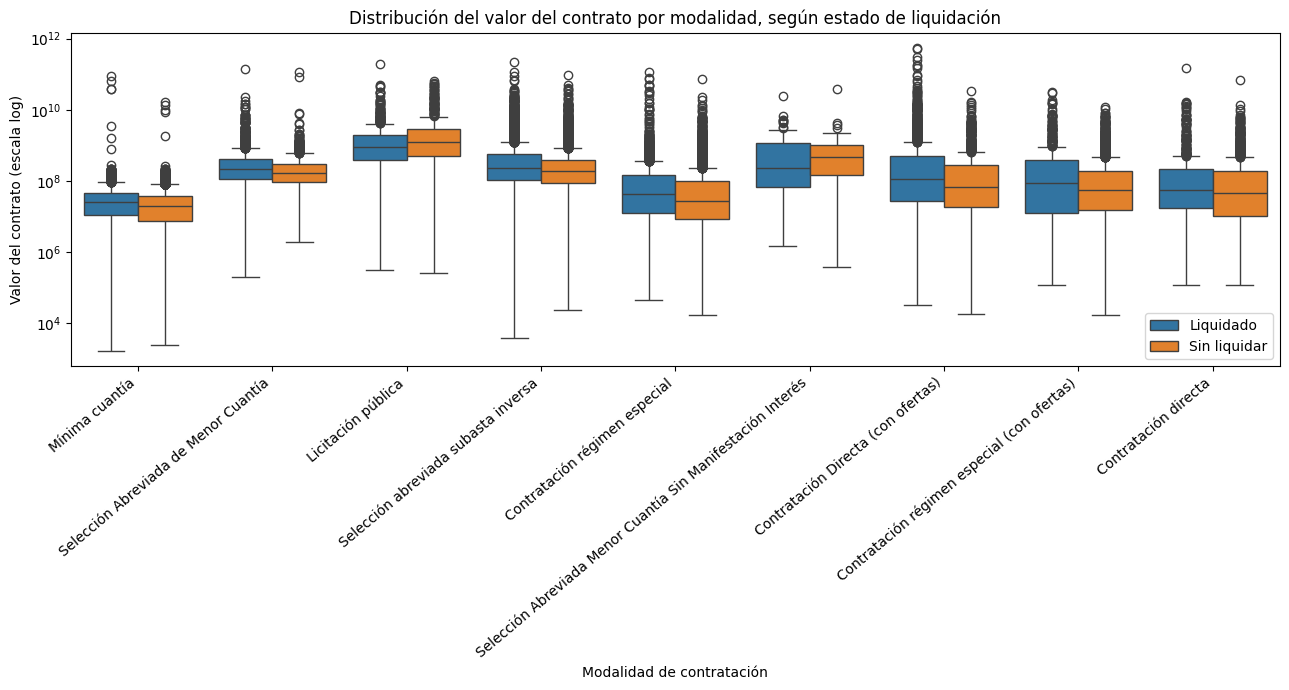

modalidad_de_contratacion                                    sin_liquidar_label
Contratación Directa (con ofertas)                           Liquidado             1.129544e+08
                                                             Sin liquidar          6.633145e+07
Contratación directa                                         Liquidado             5.388650e+07
                                                             Sin liquidar          4.500000e+07
Contratación régimen especial                                Liquidado             4.186535e+07
                                                             Sin liquidar          2.781744e+07
Contratación régimen especial (con ofertas)                  Liquidado             8.740419e+07
                                                             Sin liquidar          5.449862e+07
Licitación pública                                           Liquidado             9.000000e+08
                                                        

In [34]:
datos_valor = df_limpio[
    df_limpio['valor_confiable'] &
    (df_limpio['valor_del_contrato'] > 0) &
    df_limpio['estado_contrato'].isin(['Cerrado', 'Terminado']) &
    df_limpio['liquidacion_confiable']
].copy()

datos_valor['sin_liquidar_label'] = np.where(datos_valor['liquidaci_n'] == 'No', 'Sin liquidar', 'Liquidado')

fig, ax = plt.subplots(figsize=(13, 7))
sns.boxplot(
    data=datos_valor,
    x='modalidad_de_contratacion',
    y='valor_del_contrato',
    hue='sin_liquidar_label',
    ax=ax
)
ax.set_yscale('log')
ax.set_xlabel('Modalidad de contratación')
ax.set_ylabel('Valor del contrato (escala log)')
ax.set_title('Distribución del valor del contrato por modalidad, según estado de liquidación')
plt.xticks(rotation=40, ha='right')
plt.legend(title='')
plt.tight_layout()
plt.show()

print(datos_valor.groupby(['modalidad_de_contratacion', 'sin_liquidar_label'])['valor_del_contrato'].median().round(0))

**Interpretación.**

En 7 de las 9 modalidades, la mediana del valor del contrato es más alta entre los contratos liquidados que entre los sin liquidar (por ejemplo, `Contratación Directa (con ofertas)` con 112.95 millones frente a 66.33 millones, o `Contratación régimen especial (con ofertas)` con 87.40 millones frente a 54.50 millones). Esto sugiere que, dentro de la mayoría de modalidades, son los contratos de menor valor los que tienden a quedar sin liquidar, posiblemente porque reciben menor prioridad administrativa de seguimiento frente a los contratos más grandes.

Hay dos excepciones claras a ese patrón. En `Licitación pública`, la mediana de los contratos sin liquidar (1221.05 millones) es mayor que la de los liquidados (900 millones). Como `Licitación pública` ya maneja los valores más altos de todas las modalidades por varios órdenes de magnitud, esto significa que los contratos sin liquidar más costosos de toda la base de datos están concentrados justamente en esta modalidad, un hallazgo con implicaciones directas para priorizar supervisión por impacto fiscal. La segunda excepción es `Selección Abreviada Menor Cuantía Sin Manifestación Interés` (472.68 millones sin liquidar frente a 227.21 millones liquidados), aunque esta modalidad tiene muy pocos contratos en total (236 según el Punto 1), por lo que esta comparación debe tomarse con cautela dado el tamaño de muestra reducido.

Para `Contratación régimen especial (con ofertas)`, la modalidad que identificamos como foco de riesgo compuesto en 3.4, el patrón sigue la tendencia general (liquidados de mayor valor que sin liquidar). Esto matiza el criterio de focalización, en esta modalidad el riesgo de no liquidación no está concentrado en sus contratos más grandes, por lo que la prioridad de supervisión ahí debería basarse en la modalidad en sí y no adicionalmente en el valor del contrato dentro de ella. En cambio, para `Licitación pública`, el valor del contrato sí es un criterio adicional relevante, dado que ahí el riesgo de no liquidación se concentra en los contratos de mayor valor.

Es importante aclarar que esta es una comparación descriptiva de medianas, no una prueba de hipótesis formal, por lo que no se debe interpretar como evidencia de significancia estadística, sino como un patrón exploratorio que enriquece el criterio de focalización.

## 4. Generación de resultados

### 4.1 Contexto y objetivo

Este análisis se realizó sobre 196391 contratos de bienes y suministros registrados en SECOP II entre 2019 y 2025. El objetivo es proponer criterios de focalización de supervisión basados en evidencia estadística, identificando qué modalidades de contratación concentran mayor riesgo de tres problemas concretos detectados en el Punto 1, adición de plazo, presupuesto no ejecutado, y cierre sin liquidar.

### 4.2 Hallazgos generales

En el Punto 1 se identificaron tres señales de desviación relevantes sobre el total de contratos. El 9.51% de los contratos tuvo adición de plazo (`dias_adicionados` mayor a cero), el 21.79% quedó cerrado o terminado sin ejecutar presupuesto (`valor_pagado` igual a cero), y el 55.31% de los contratos cerrados o terminados quedó sin liquidar. Adicionalmente se documentaron y trataron 9 problemas de calidad de datos (`P1` a `P9`) de forma no destructiva, preservando las 196391 filas originales mediante banderas de confiabilidad en lugar de eliminar registros.

En el Punto 3 se contrastó si `modalidad_de_contratacion` explica cada una de estas tres señales. En los tres casos la prueba estadística resultó significativa dado el tamaño de la muestra, pero el tamaño del efecto fue distinto en cada caso. Para adición de plazo el efecto global fue pequeño (eta cuadrado de 0.022), para no ejecución también pequeño (Cramér's V de 0.0931), y para cierre sin liquidar fue el más fuerte de los tres (Cramér's V de 0.1748). En todos los casos, sin embargo, existieron modalidades puntuales con diferencias porcentuales muy por encima del umbral de relevancia práctica definido, aunque el efecto global agregado fuera débil.

### 4.3 Criterios de focalización propuestos

**Foco transversal, `Contratación régimen especial (con ofertas)`.** Esta modalidad presentó el porcentaje más alto de no ejecución (38.64% frente a un grupo mayoritario cercano a 20%) y el porcentaje más alto de cierre sin liquidar (81.74% frente a un promedio general de 55.31%). Es la única modalidad que aparece como grupo de riesgo en dos de las tres señales analizadas, lo que la convierte en el candidato más claro para supervisión prioritaria de forma general, sin necesidad de filtrar adicionalmente por valor del contrato dentro de esta modalidad, dado que ahí el riesgo de no liquidación no se concentra en sus contratos más costosos.

**Foco específico de plazos y de alto valor, `Licitación pública`.** Esta modalidad tiene la adición de plazo promedio más alta (18.65 días) y, aunque su porcentaje de no ejecución y de cierre sin liquidar están por debajo del promedio general, dentro de esta modalidad los contratos sin liquidar tienden a ser los de mayor valor (mediana de 1221.05 millones frente a 900 millones en los liquidados). Esto sugiere priorizar supervisión de los contratos de `Licitación pública` de mayor cuantía específicamente por riesgo de plazos y de cierre financiero tardío, más que por volumen general de incumplimiento.

**No priorizar por volumen, `Mínima cuantía`.** Esta modalidad concentra el 60% de todos los contratos de la base de datos (117753 de 196391), pero sus porcentajes de no ejecución (20.06%) y de cierre sin liquidar (55.70%) están cerca del promedio general, sin destacar como grupo de riesgo. Priorizar supervisión aquí por volumen, sin evidencia de riesgo diferencial, sería ineficiente frente a modalidades con señales más claras.

### 4.4 Limitaciones del análisis

Este análisis evaluó `modalidad_de_contratacion` como único predictor categórico de cada señal de desviación, de forma univariada frente a cada variable objetivo. No se ajustó un modelo multivariado (por ejemplo una regresión logística) que controle simultáneamente por otras variables como el valor del contrato, la entidad contratante o el sector, por lo que no puede descartarse que parte de la asociación observada se explique por variables no incluidas en este análisis.

Con un tamaño de muestra de casi 200000 contratos, casi cualquier diferencia entre grupos resulta estadísticamente significativa, incluso cuando el tamaño del efecto es pequeño. Por esta razón, todas las conclusiones de este informe se basaron en umbrales de relevancia práctica definidos antes de cada prueba (10 puntos porcentuales o 15 días de diferencia, según el caso), y no únicamente en el valor p.

Las banderas `no_ejecutado` y `sin_liquidar` son proxies construidos a partir de reglas simples (`valor_pagado` igual a cero, y `liquidaci_n` igual a `No`), y no capturan necesariamente las causas administrativas detrás de cada caso. Además, las comparaciones de cierre sin liquidar se hicieron solo sobre el subconjunto de contratos marcados como confiables por la bandera `liquidacion_confiable` (101054 de 196391 contratos cerrados o terminados), lo que reduce el tamaño de muestra disponible y podría introducir sesgo si los registros excluidos no son aleatorios respecto a la modalidad de contratación.

Finalmente, la modalidad `Selección Abreviada Menor Cuantía Sin Manifestación Interés` tiene muy pocos contratos en total (236), por lo que cualquier hallazgo específico sobre ella debe tratarse con cautela y no como una conclusión robusta.

Este análisis identifica asociaciones estadísticas y patrones descriptivos, no relaciones causales. Cualquier criterio de focalización propuesto aquí debería validarse con conocimiento del proceso administrativo real antes de implementarse como política de supervisión.